In [61]:
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from pathlib import Path

# ACC ITR p-values

In [62]:
experiments = [
        exp.name for exp in Path("../destine_results_multiple_norm_reg/").iterdir() if exp.is_dir()
]
df_list = []
for experiment in experiments:
    exp_path = Path("../destine_results_multiple_norm_reg/").joinpath(experiment)
    for setup in exp_path.iterdir():
        if setup.is_dir():
            print(f"Experiment: {experiment}, Setup: {setup.name}")
            metrics_path = setup.joinpath("metricas.csv")
            if metrics_path.exists():
                df = pd.read_csv(metrics_path)
                df["experiment"] = experiment
                df["window"] = float(setup.name.split("_")[-2])
                df["frequency"] = int(setup.name.split("_")[-4])
                df["id"] = int(setup.name.split("_")[0])
                df_list.append(df[(df["frequency"] == 3) & (df["window"] == 1.0)])  # Filter for frequency 3 Hz and target window
results = pd.concat(df_list, ignore_index=True)

Experiment: eegnetfbcca, Setup: 10_users_3_freqs_0.4_s
Experiment: eegnetfbcca, Setup: 10_users_3_freqs_1.0_s
Experiment: eegnetfbcca, Setup: 10_users_6_freqs_1.0_s
Experiment: eegnetcca, Setup: 10_users_3_freqs_0.4_s
Experiment: eegnetcca, Setup: 10_users_3_freqs_1.0_s
Experiment: eegnetcca, Setup: 10_users_6_freqs_1.0_s
Experiment: eegnet, Setup: 10_users_3_freqs_0.4_s
Experiment: eegnet, Setup: 10_users_3_freqs_1.0_s
Experiment: eegnet, Setup: 10_users_6_freqs_1.0_s
Experiment: cca, Setup: 10_users_3_freqs_0.4_s
Experiment: cca, Setup: 10_users_3_freqs_1.0_s
Experiment: cca, Setup: 10_users_6_freqs_1.0_s


In [63]:
results

,usuario,acuracia,recall,f1-score,experiment,window,frequency,id
0,carlos,0.458333,0.458333,0.446473,eegnetfbcca,1.0,3,10
1,george,0.625000,0.625000,0.624172,eegnetfbcca,1.0,3,10
2,guilherme,0.368056,0.368056,0.338391,eegnetfbcca,1.0,3,10
3,harlei,0.413194,0.413194,0.377065,eegnetfbcca,1.0,3,10
4,heiko,0.774306,0.774306,0.770680,eegnetfbcca,1.0,3,10
5,joao,0.715278,0.715278,0.718242,eegnetfbcca,1.0,3,10
6,luis,0.489583,0.489583,0.487252,eegnetfbcca,1.0,3,10
7,luisa,0.430556,0.430556,0.414679,eegnetfbcca,1.0,3,10
8,sarah,0.628472,0.628472,0.622347,eegnetfbcca,1.0,3,10
9,thiago,0.600694,0.600694,0.597795,eegnetfbcca,1.0,3,10


In [64]:
from math import log2

results_means = (
    results.groupby(["experiment", "window"])
    .agg({"acuracia": ["mean", "sem"]})  # Using standard error of the mean
    .reset_index()
)
print(results_means)
results_means.columns = ["experiment", "window", "acuracia", "acuracia_sem"]


# ============ ITR CALCULATION ============
def itr(n, p, t):
    """
    Calculate Information Transfer Rate (ITR) in bits/minute

    Parameters:
    n: number of classes/targets
    p: accuracy (between 0 and 1)
    t: time per trial in seconds
    """
    if p < 0 or 1 < p:
        raise ValueError(
            "stats:itr:BadInputValue " + "Accuracy need to be between 0 and 1."
        )
    elif p < 1 / n:
        itr_value = 0
    elif p == 1:
        itr_value = log2(n) * 60 / t
    else:
        itr_value = (log2(n) + p * log2(p) + (1 - p) * log2((1 - p) / (n - 1))) * 60 / t
    return itr_value


# Calculate ITR for each experiment-window combination
n_classes = 8  # 8-15 Hz frequencies
tempo_desvio_ocular = 0.55  # Visual delay time in seconds

# Apply ITR calculation to each row (simpler approach)
# Total time per trial = window length + visual delay
results["itr"] = results.apply(
    lambda row: itr(n_classes, row["acuracia"], row["window"] + tempo_desvio_ocular),
    axis=1,
)

# Group by experiment and window to get mean and SEM of ITR
results_itr = (
    results.groupby(["experiment", "window"])
    .agg({"itr": ["mean", "sem"]})
    .reset_index()
)
results_itr.columns = ["experiment", "window", "itr", "itr_sem"]

print("\nITR values by experiment and window:")
print(results_itr)

    experiment window  acuracia          
                           mean       sem
0          cca    1.0  0.448264  0.030532
1       eegnet    1.0  0.588542  0.033289
2    eegnetcca    1.0  0.553819  0.038510
3  eegnetfbcca    1.0  0.550347  0.043477

ITR values by experiment and window:
    experiment  window        itr   itr_sem
0          cca     1.0  18.710313  3.201876
1       eegnet     1.0  34.751815  4.297533
2    eegnetcca     1.0  30.807888  4.897284
3  eegnetfbcca     1.0  30.811253  5.430689


In [65]:
from scipy import stats

# Calculate p-values for paired t-tests between experiments at each window
# For each window, compare each pair of experiments
p_values_dict = {}

for window in sorted(results["window"].unique()):
    window_data = results[results["window"] == window]
    experiments_list = sorted(window_data["experiment"].unique())

    p_values_dict[window] = {}

    for i, exp1 in enumerate(experiments_list):
        for exp2 in experiments_list[i + 1 :]:
            data1 = window_data[window_data["experiment"] == exp1]["acuracia"].values
            print(exp1, window_data[window_data["experiment"] == exp1]["acuracia"])
            data2 = window_data[window_data["experiment"] == exp2]["acuracia"].values
            print(exp2, window_data[window_data["experiment"] == exp2]["acuracia"])

            # Paired t-test
            t_stat, p_value = stats.ttest_rel(data1, data2)
            p_values_dict[window][(exp1, exp2)] = p_value


# Create a function to get significance marker
def get_significance(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


print("P-values from paired t-tests:")
for window, pairs in p_values_dict.items():
    print(f"\nWindow: {window}s")
    for (exp1, exp2), p_val in pairs.items():
        sig = get_significance(p_val)
        print(f"  {exp1} vs {exp2}: p={p_val:.4f} {sig}")

cca 30    0.340278
31    0.437500
32    0.361111
33    0.385417
34    0.597222
35    0.413194
36    0.388889
37    0.611111
38    0.527778
39    0.420139
Name: acuracia, dtype: float64
eegnet 20    0.461806
21    0.642361
22    0.461806
23    0.447917
24    0.756944
25    0.607639
26    0.565972
27    0.586806
28    0.680556
29    0.673611
Name: acuracia, dtype: float64
cca 30    0.340278
31    0.437500
32    0.361111
33    0.385417
34    0.597222
35    0.413194
36    0.388889
37    0.611111
38    0.527778
39    0.420139
Name: acuracia, dtype: float64
eegnetcca 10    0.402778
11    0.656250
12    0.465278
13    0.427083
14    0.777778
15    0.597222
16    0.510417
17    0.447917
18    0.642361
19    0.611111
Name: acuracia, dtype: float64
cca 30    0.340278
31    0.437500
32    0.361111
33    0.385417
34    0.597222
35    0.413194
36    0.388889
37    0.611111
38    0.527778
39    0.420139
Name: acuracia, dtype: float64
eegnetfbcca 0    0.458333
1    0.625000
2    0.368056
3    0.41319

In [66]:
# ============ CALCULATE P-VALUES FOR ITR ============
# Calculate separate p-values for ITR (independent of accuracy p-values)

p_values_dict_itr = {}

for window in sorted(results["window"].unique()):
    window_data = results[results["window"] == window]
    experiments_list = sorted(window_data["experiment"].unique())

    p_values_dict_itr[window] = {}

    for i, exp1 in enumerate(experiments_list):
        for exp2 in experiments_list[i + 1 :]:
            # Use ITR values instead of accuracy
            data1 = window_data[window_data["experiment"] == exp1]["itr"].values
            data2 = window_data[window_data["experiment"] == exp2]["itr"].values

            # Paired t-test on ITR values
            t_stat, p_value = stats.ttest_rel(data1, data2)
            p_values_dict_itr[window][(exp1, exp2)] = p_value


print("\nP-values from paired t-tests (ITR):")
for window, pairs in p_values_dict_itr.items():
    print(f"\nWindow: {window}s")
    for (exp1, exp2), p_val in pairs.items():
        sig = get_significance(p_val)
        print(f"  {exp1} vs {exp2}: p={p_val:.4f} {sig}")


P-values from paired t-tests (ITR):

Window: 1.0s
  cca vs eegnet: p=0.0008 ***
  cca vs eegnetcca: p=0.0209 *
  cca vs eegnetfbcca: p=0.0408 *
  eegnet vs eegnetcca: p=0.0571 ns
  eegnet vs eegnetfbcca: p=0.1985 ns
  eegnetcca vs eegnetfbcca: p=0.9988 ns


# Checks

In [67]:
from scipy import stats
import matplotlib.pyplot as plt

# ============ DIAGNOSTIC TESTS FOR STATISTICAL ANALYSIS ============
print("=" * 70)
print("DIAGNOSTIC TESTS FOR CHOOSING APPROPRIATE STATISTICAL TEST")
print("=" * 70)

# 1. Check data structure
print("\n1. DATA STRUCTURE:")
print(f"   - Total observations: {len(results)}")
print(f"   - Unique experiments: {results['experiment'].nunique()}")
print(f"   - Unique windows: {results['window'].nunique()}")
print(f"   - Unique users: {results['usuario'].nunique()}")
print(
    f"   - Sample per experiment-window: {results.groupby(['experiment', 'window']).size().unique()}"
)

# 2. Test for normality (Shapiro-Wilk test) for one example
print("\n2. NORMALITY TESTS (Shapiro-Wilk at 0.4s window for each experiment):")
window = 0.4
for exp in sorted(results["experiment"].unique()):
    data = results[(results["experiment"] == exp) & (results["window"] == window)][
        "acuracia"
    ].values
    if len(data) >= 3:  # Shapiro-Wilk requires at least 3 samples
        stat, p_val = stats.shapiro(data)
        normal = "✓ Normal" if p_val > 0.05 else "✗ Not Normal"
        print(f"   {exp:15s}: W={stat:.4f}, p={p_val:.4f} {normal}")

# 3. Check for equal variances (Levene's test)
print("\n3. EQUAL VARIANCES TEST (Levene's at 0.4s window):")
window = 0.4
data_by_exp = [
    results[(results["experiment"] == exp) & (results["window"] == window)][
        "acuracia"
    ].values
    for exp in sorted(results["experiment"].unique())
]
stat, p_val = stats.levene(*data_by_exp)
equal_var = "✓ Equal variances" if p_val > 0.05 else "✗ Unequal variances"
print(f"   Levene's test: F={stat:.4f}, p={p_val:.4f} {equal_var}")

# 4. Paired t-test vs Wilcoxon example
print("\n4. COMPARISON: Paired t-test vs Wilcoxon (CCA_dnn vs dnn at 0.4s):")
window = 0.4
exp1, exp2 = "CCA_dnn", "dnn"
# Get paired data for same users
data1 = results[(results["experiment"] == exp1) & (results["window"] == window)][
    "acuracia"
].values
data2 = results[(results["experiment"] == exp2) & (results["window"] == window)][
    "acuracia"
].values

if len(data1) == len(data2):
    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(data1, data2)
    # Wilcoxon signed-rank test
    w_stat, p_wilcoxon = stats.wilcoxon(data1, data2)

    print(f"   Paired t-test:        t={t_stat:.4f}, p={p_ttest:.6f}")
    print(f"   Wilcoxon test:        W={w_stat:.4f}, p={p_wilcoxon:.6f}")
    print(f"   Mean difference: {np.mean(data1 - data2):.4f}")
    print(f"   Std of difference: {np.std(data1 - data2):.4f}")

print("\n" + "=" * 70)
print("RECOMMENDATIONS:")
print("=" * 70)
print("✓ PAIRED T-TEST is appropriate if:")
print("  - Differences are normally distributed (check Q-Q plot)")
print("  - Sample size is adequate (n=10 is borderline)")
print("  - Only comparing 2 experiments at a time")
print("\n✓ WILCOXON TEST is better if:")
print("  - Data violates normality assumption")
print("  - You have outliers or skewed distributions")
print("\n✓ LINEAR MIXED MODELS are best if:")
print("  - Comparing multiple experiments simultaneously")
print("  - Accounting for user-level random effects")
print("  - Maximum statistical power for your design")
print("=" * 70)

DIAGNOSTIC TESTS FOR CHOOSING APPROPRIATE STATISTICAL TEST

1. DATA STRUCTURE:
   - Total observations: 40
   - Unique experiments: 4
   - Unique windows: 1
   - Unique users: 10
   - Sample per experiment-window: [10]

2. NORMALITY TESTS (Shapiro-Wilk at 0.4s window for each experiment):

3. EQUAL VARIANCES TEST (Levene's at 0.4s window):
   Levene's test: F=nan, p=nan ✗ Unequal variances

4. COMPARISON: Paired t-test vs Wilcoxon (CCA_dnn vs dnn at 0.4s):
   Paired t-test:        t=nan, p=nan
   Wilcoxon test:        W=nan, p=nan
   Mean difference: nan
   Std of difference: nan

RECOMMENDATIONS:
✓ PAIRED T-TEST is appropriate if:
  - Differences are normally distributed (check Q-Q plot)
  - Sample size is adequate (n=10 is borderline)
  - Only comparing 2 experiments at a time

✓ WILCOXON TEST is better if:
  - Data violates normality assumption
  - You have outliers or skewed distributions

✓ LINEAR MIXED MODELS are best if:
  - Comparing multiple experiments simultaneously
  - Acco

/tmp/ipykernel_3489068/2016304303.py:40: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_val = stats.levene(*data_by_exp)
/tmp/ipykernel_3489068/2016304303.py:58: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_ttest = stats.ttest_rel(data1, data2)
/home/mateuschinelatto/miniforge3/envs/bci/lib/python3.12/site-packages/scipy/_lib/_util.py:951: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)
/home/mateuschinelatto/miniforge3/envs/bci/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mateuschinelatto/miniforge3/envs/bci/lib/python3.12/site-packages/nu

In [68]:
results_means

,experiment,window,acuracia,acuracia_sem
0,cca,1.0,0.448264,0.030532
1,eegnet,1.0,0.588542,0.033289
2,eegnetcca,1.0,0.553819,0.038510
3,eegnetfbcca,1.0,0.550347,0.043477


# Graficos

In [69]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Create figure with two subplots side by side
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
# sns.set_theme(style="white")

# # Custom color palette for paired experiments
# custom_palette = {
#     "CCA": "#156b00",
#     "CCA_EEGNET_8_2": "#6baed6",
#     "pre-CCA_eegnet_original": "#0020d3",
#     "EEGNET_8_2": "#a66708",
#     "pre-eegnet": "#8d3800",
#     "CCA_DNN": "#56ff97",
#     "CCA_dnn_8_10": "#347a0b",
#     "DNN": "#ff7b00",
# }

# results_means_copy = results_means.copy()

# results_means_copy["acuracia"] = (
#     results_means_copy["acuracia"] * 100
# )  # Convert to percentage
# results_means_copy["acuracia_sem"] = (
#     results_means_copy["acuracia_sem"] * 100
# )  # Convert to percentage


# # ============ PLOT 1: ACCURACY ============
# ax = sns.lineplot(
#     data=results_means_copy,
#     x="window",
#     y="acuracia",
#     hue="experiment",
#     marker="o",
#     markersize=10,
#     linewidth=2.5,
#     palette=custom_palette,
#     ax=ax1,
# )

# # Get colors for accuracy plot
# colors = {}
# lines = [line for line in ax1.get_lines()]
# experiment_list = sorted(results_means["experiment"].unique())
# for i, experiment in enumerate(experiment_list):
#     colors[experiment] = lines[i].get_color()

# # Add shaded areas for accuracy
# for experiment in results_means_copy["experiment"].unique():
#     data = results_means_copy[results_means_copy["experiment"] == experiment]
#     data = data.sort_values("window")
#     ax1.fill_between(
#         data["window"],
#         data["acuracia"] - data["acuracia_sem"],
#         data["acuracia"] + data["acuracia_sem"],
#         alpha=0.2,
#         color=colors[experiment],
#     )

# # Add significance markers for accuracy plot
# y_max_acc = results_means_copy["acuracia"].max()
# y_offset_acc = y_max_acc * 0.06
# comparison_pairs = [
#     ("CCA_dnn", "dnn", "◆"),
#     ("CCA_eegnet", "eegnet", "■"),
# ]

# for window in sorted(results["window"].unique()):
#     window_results = results_means_copy[results_means_copy["window"] == window]
#     max_acc = window_results["acuracia"].max()
#     sig_y_base = max_acc + y_offset_acc

#     for idx, (exp1, exp2, symbol) in enumerate(comparison_pairs):
#         if window in p_values_dict:
#             p_val = None
#             if (exp1, exp2) in p_values_dict[window]:
#                 p_val = p_values_dict[window][(exp1, exp2)]
#             elif (exp2, exp1) in p_values_dict[window]:
#                 p_val = p_values_dict[window][(exp2, exp1)]

#             if p_val is not None and p_val < 0.05:
#                 sig = get_significance(p_val)
#                 x_pos = window
#                 y_pos = sig_y_base + idx * 0.04
#                 marker_text = f"{symbol} {sig}"
#                 ax1.text(
#                     x_pos,
#                     y_pos,
#                     marker_text,
#                     ha="center",
#                     fontsize=11,
#                     fontweight="bold",
#                     va="bottom",
#                 )

# ax1.set_xlabel("Tamanho da janela (s)", fontsize=16, fontweight="bold")
# ax1.set_xticks(results_means["window"].unique())
# ax1.set_ylabel("Acurácia (%)", fontsize=16, fontweight="bold")
# ax1.set_title("Acurácia por tamanho do sinal", fontsize=17, fontweight="bold")
# ax1.legend(title="Experimento", loc="lower right", frameon=True, shadow=True)
# ax1.set_ylim(top=100)
# ax1.grid(axis="y", alpha=0.3, linestyle="--")

# # ============ PLOT 2: ITR ============
# ax = sns.lineplot(
#     data=results_itr,
#     x="window",
#     y="itr",
#     hue="experiment",
#     marker="o",
#     markersize=10,
#     linewidth=2.5,
#     palette=custom_palette,
#     ax=ax2,
# )

# # Get colors for ITR plot
# colors_itr = {}
# lines_itr = [line for line in ax2.get_lines()]
# for i, experiment in enumerate(experiment_list):
#     colors_itr[experiment] = lines_itr[i].get_color()

# # Add shaded areas for ITR
# for experiment in results_itr["experiment"].unique():
#     data = results_itr[results_itr["experiment"] == experiment]
#     data = data.sort_values("window")
#     ax2.fill_between(
#         data["window"],
#         data["itr"] - data["itr_sem"],
#         data["itr"] + data["itr_sem"],
#         alpha=0.2,
#         color=colors_itr[experiment],
#     )

# # Add significance markers for ITR plot (using ITR p-values, not accuracy p-values)
# y_max_itr = results_itr["itr"].max()
# y_offset_itr = y_max_itr * 0.06

# for window in sorted(results["window"].unique()):
#     window_results = results_itr[results_itr["window"] == window]
#     max_itr = window_results["itr"].max()
#     sig_y_base = max_itr + y_offset_itr

#     for idx, (exp1, exp2, symbol) in enumerate(comparison_pairs):
#         if window in p_values_dict_itr:
#             p_val = None
#             if (exp1, exp2) in p_values_dict_itr[window]:
#                 p_val = p_values_dict_itr[window][(exp1, exp2)]
#             elif (exp2, exp1) in p_values_dict_itr[window]:
#                 p_val = p_values_dict_itr[window][(exp2, exp1)]

#             if p_val is not None and p_val < 0.05:
#                 sig = get_significance(p_val)
#                 x_pos = window
#                 y_pos = sig_y_base + idx * 0.04
#                 marker_text = f"{symbol} {sig}"
#                 ax2.text(
#                     x_pos,
#                     y_pos,
#                     marker_text,
#                     ha="center",
#                     fontsize=11,
#                     fontweight="bold",
#                     va="bottom",
#                 )

# ax2.set_xlabel("Tamanho do sinal (s)", fontsize=16, fontweight="bold")
# ax2.set_xticks(results_itr["window"].unique())
# ax2.set_ylabel("ITR (bpm)", fontsize=16, fontweight="bold")
# ax2.set_title("ITR por tamanho do sinal", fontsize=17, fontweight="bold")
# ax2.legend(title="Experimento", loc="lower right", frameon=True, shadow=True)
# ax2.set_ylim(top=90)
# ax2.grid(axis="y", alpha=0.3, linestyle="--")

# # Add text box explaining symbols (p-values legend)
# textstr = (
#     "◆ CCA_dnn vs dnn\n■ CCA_eegnet vs eegnet\n*p < 0.05, **p < 0.01, ***p < 0.001"
# )
# props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
# fig.text(
#     0.5,
#     0.02,
#     textstr,
#     ha="center",
#     fontsize=11,
#     bbox=props,
#     family="monospace",
# )

# # Overall figure adjustments
# plt.tight_layout()
# plt.subplots_adjust(bottom=0.15)  # Make room for the legend box

# # Show the plot
# plt.show()

# # Optional: Save the figure
# fig.savefig(
#     "accuracy_itr_comparison.png",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
# )

In [70]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Create figure with two subplots side by side (bar version)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
# sns.set_theme(style="white")

# # Custom color palette for experiments
# custom_palette = {
#     "CCA_CAR": "#30e702",
#     # "CCA": "#156b00",
#     # "EEGNET_8_2": "#ff5537",
#     "EEGNET_8_2_CAR": "#8d3800",
#     "CCA_EEGNET_8_2": "#0044ff",
#     # "CCA_EEGNET_8_2_CAR": "#2e00d3",
#     "CCA_ALL_EEGNET_8_2": "#0000ff",
#     "FBCCA_EEGNET": "#6b84d6",  
#     "FBCCA_ALL_EEGNET": "#0044ff",
#     # "DNN_CAR": "#7a6f0b",
# #     "DNN": "#ff9900c7",
# #     "CCA_DNN": "#00ffff",
#     # "CCA_DNN_CAR": "#78ff56",
#     # "FBCCA_DNN": "#fd87f7",
#     # "SMALLDNN": "#fd87f7",
#     # "SMALLDNN_CAR": "#e100ff",
# #     "SMALLDNN_CCA": "#ff0000",
#     # "SMALLDNN_CCA_CAR": "#9c0303",
#     # "FBCCA_SMALLDNN": "#9c0303",
# }

# # Keep only experiments available in current results
# available_experiments = sorted(results_means["experiment"].unique())
# experiment_order = [exp for exp in custom_palette.keys() if exp in available_experiments]
# if not experiment_order:
#     experiment_order = available_experiments

# # Only show 1.0s window
# target_window = 1.0
# windows = np.array([target_window])
# x = np.arange(len(windows))
# total_width = 0.8
# bar_width = total_width / max(len(experiment_order), 1)

# # ============ PLOT 1: ACCURACY (BAR + ERROR BARS, 1s only) ============
# results_means_copy = results_means.copy()
# results_means_copy["acuracia"] = results_means_copy["acuracia"] * 100
# results_means_copy["acuracia_sem"] = results_means_copy["acuracia_sem"] * 100

# acc_lows, acc_highs = [], []
# for i, experiment in enumerate(experiment_order):
#     exp_data = results_means_copy[results_means_copy["experiment"] == experiment].copy()
#     exp_data = exp_data[np.isclose(exp_data["window"], target_window)].set_index("window").reindex(windows)

#     y = exp_data["acuracia"].values.astype(float)
#     yerr = exp_data["acuracia_sem"].values.astype(float)
#     offsets = x - total_width / 2 + (i + 0.5) * bar_width

#     ax1.bar(
#         offsets,
#         y,
#         width=bar_width,
#         yerr=yerr,
#         capsize=4,
#         label=experiment,
#         color=custom_palette.get(experiment),
#         alpha=0.9,
#         edgecolor="black",
#         linewidth=0.5,
#     )

#     if np.isfinite(y).any() and np.isfinite(yerr).any():
#         acc_lows.extend((y - yerr)[np.isfinite(y - yerr)])
#         acc_highs.extend((y + yerr)[np.isfinite(y + yerr)])

# ax1.set_xlabel("Tamanho da janela (s)", fontsize=14, fontweight="bold")
# ax1.set_xticks(x)
# ax1.set_xticklabels([f"{target_window:.1f}"] * len(x))
# ax1.set_ylabel("Acurácia (%)", fontsize=14, fontweight="bold")
# ax1.set_title("Acurácia em 1.0s (Barras)", fontsize=15, fontweight="bold")
# ax1.legend(title="Experimento", loc="best", frameon=True, shadow=True)
# ax1.grid(axis="y", alpha=0.3, linestyle="--")

# if acc_highs:
#     y_max = max(acc_highs)
#     pad = max(y_max * 0.1, 1.0)
#     ax1.set_ylim(0, y_max + pad)
# else:
#     ax1.set_ylim(bottom=0)

# # ============ PLOT 2: ITR (BAR + ERROR BARS, 1s only) ============
# results_itr_copy = results_itr.copy()

# itr_lows, itr_highs = [], []
# for i, experiment in enumerate(experiment_order):
#     exp_data = results_itr_copy[results_itr_copy["experiment"] == experiment].copy()
#     exp_data = exp_data[np.isclose(exp_data["window"], target_window)].set_index("window").reindex(windows)

#     y = exp_data["itr"].values.astype(float)
#     yerr = exp_data["itr_sem"].values.astype(float)
#     offsets = x - total_width / 2 + (i + 0.5) * bar_width

#     ax2.bar(
#         offsets,
#         y,
#         width=bar_width,
#         yerr=yerr,
#         capsize=4,
#         label=experiment,
#         color=custom_palette.get(experiment),
#         alpha=0.9,
#         edgecolor="black",
#         linewidth=0.5,
#     )

#     if np.isfinite(y).any() and np.isfinite(yerr).any():
#         itr_lows.extend((y - yerr)[np.isfinite(y - yerr)])
#         itr_highs.extend((y + yerr)[np.isfinite(y + yerr)])

# ax2.set_xlabel("Tamanho do sinal (s)", fontsize=14, fontweight="bold")
# ax2.set_xticks(x)
# ax2.set_xticklabels([f"{target_window:.1f}"] * len(x))
# ax2.set_ylabel("ITR (bpm)", fontsize=14, fontweight="bold")
# ax2.set_title("ITR em 1.0s (Barras)", fontsize=15, fontweight="bold")
# ax2.legend(title="Experimento", loc="best", frameon=True, shadow=True)
# ax2.grid(axis="y", alpha=0.3, linestyle="--")

# if itr_highs:
#     y_max = max(itr_highs)
#     pad = max(y_max * 0.1, 0.5)
#     ax2.set_ylim(0, y_max + pad)
# else:
#     ax2.set_ylim(bottom=0)

# plt.tight_layout()
# plt.show()

# fig.savefig(
#     "accuracy_itr_comparison_bars_1s_35_40_eegnets_all.png",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
# )

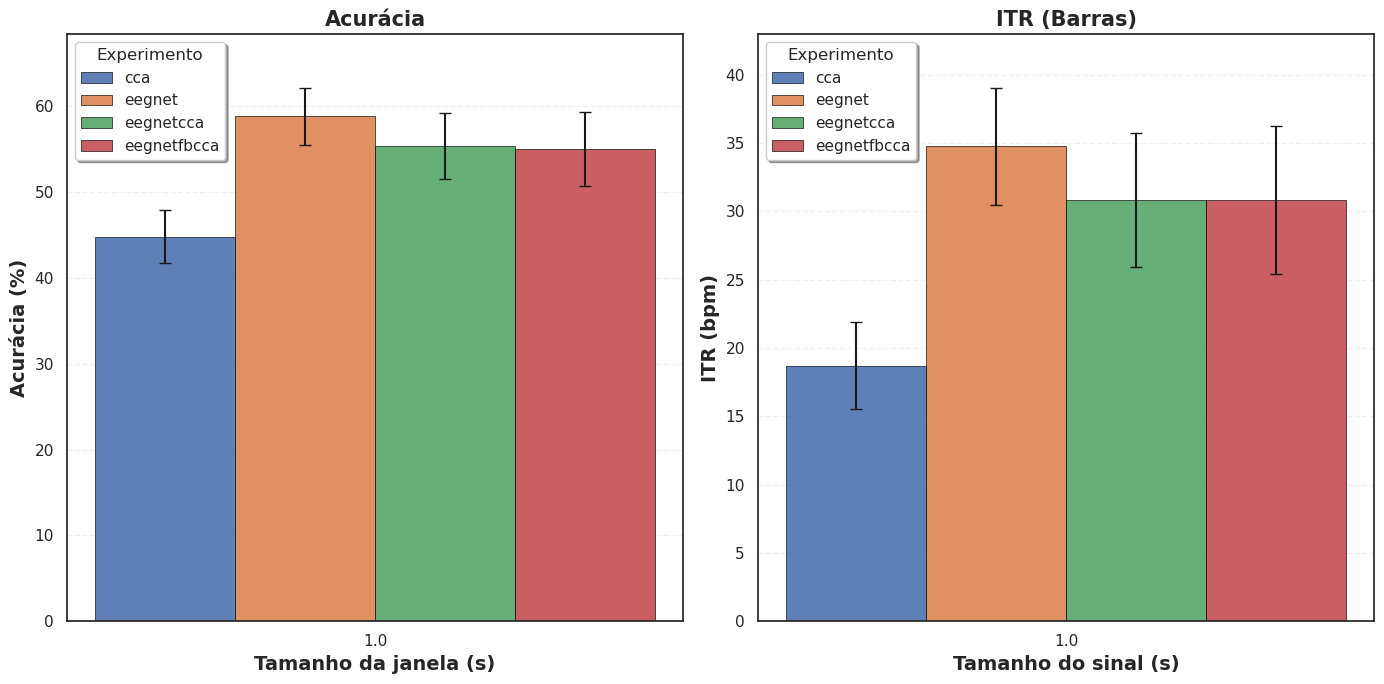

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create figure with two subplots side by side (bar version)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
sns.set_theme(style="white")

# Custom color palette for experiments
custom_palette = {
    "cca": "#30e702",
    "eegnet": "#8d3800",
    "eegnetcca": "#00e1ff",
    "eegnetcca_joint": "#0062d3",
    "eegnetfbcca": "#6b84d6",
    "eegnetfbcca_joint": "#6200ff",
    # "dnn": "#ff9900c7",
    # "dnncca": "#00ffff",
    # "dnncca_joint": "#78ff56",
    # "dnn_fbcca": "#fd87f7",
    # "dnn_fbcca_joint": "#9c0303",
}

# Keep only experiments available in current results
available_experiments = sorted(results_means["experiment"].unique())
experiment_order = [exp for exp in custom_palette.keys() if exp in available_experiments]
if not experiment_order:
    experiment_order = available_experiments

# Only show 1.0s window
target_window = 1.0
windows = np.array([target_window])
x = np.arange(len(windows))
total_width = 0.8
bar_width = total_width / max(len(experiment_order), 1)

# ============ PLOT 1: ACCURACY (BAR + ERROR BARS, 1s only) ============
results_means_copy = results_means.copy()
results_means_copy["acuracia"] = results_means_copy["acuracia"] * 100
results_means_copy["acuracia_sem"] = results_means_copy["acuracia_sem"] * 100

acc_lows, acc_highs = [], []
for i, experiment in enumerate(experiment_order):
    exp_data = results_means_copy[results_means_copy["experiment"] == experiment].copy()
    exp_data = exp_data[np.isclose(exp_data["window"], target_window)].set_index("window").reindex(windows)

    y = exp_data["acuracia"].values.astype(float)
    yerr = exp_data["acuracia_sem"].values.astype(float)
    offsets = x - total_width / 2 + (i + 0.5) * bar_width

    ax1.bar(
        offsets,
        y,
        width=bar_width,
        yerr=yerr,
        capsize=4,
        label=experiment,
        # color=custom_palette.get(experiment),
        alpha=0.9,
        edgecolor="black",
        linewidth=0.5,
    )

    if np.isfinite(y).any() and np.isfinite(yerr).any():
        acc_lows.extend((y - yerr)[np.isfinite(y - yerr)])
        acc_highs.extend((y + yerr)[np.isfinite(y + yerr)])

ax1.set_xlabel("Tamanho da janela (s)", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{target_window:.1f}"] * len(x))
ax1.set_ylabel("Acurácia (%)", fontsize=14, fontweight="bold")
ax1.set_title("Acurácia", fontsize=15, fontweight="bold")
ax1.legend(title="Experimento", loc="best", frameon=True, shadow=True)
ax1.grid(axis="y", alpha=0.3, linestyle="--")

if acc_highs:
    y_max = max(acc_highs)
    pad = max(y_max * 0.1, 1.0)
    ax1.set_ylim(0, y_max + pad)
else:
    ax1.set_ylim(bottom=0)

# ============ PLOT 2: ITR (BAR + ERROR BARS, 1s only) ============
results_itr_copy = results_itr.copy()

itr_lows, itr_highs = [], []
for i, experiment in enumerate(experiment_order):
    exp_data = results_itr_copy[results_itr_copy["experiment"] == experiment].copy()
    exp_data = exp_data[np.isclose(exp_data["window"], target_window)].set_index("window").reindex(windows)

    y = exp_data["itr"].values.astype(float)
    yerr = exp_data["itr_sem"].values.astype(float)
    offsets = x - total_width / 2 + (i + 0.5) * bar_width

    ax2.bar(
        offsets,
        y,
        width=bar_width,
        yerr=yerr,
        capsize=4,
        label=experiment,
        # color=custom_palette.get(experiment),
        alpha=0.9,
        edgecolor="black",
        linewidth=0.5,
    )

    if np.isfinite(y).any() and np.isfinite(yerr).any():
        itr_lows.extend((y - yerr)[np.isfinite(y - yerr)])
        itr_highs.extend((y + yerr)[np.isfinite(y + yerr)])

ax2.set_xlabel("Tamanho do sinal (s)", fontsize=14, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels([f"{target_window:.1f}"] * len(x))
ax2.set_ylabel("ITR (bpm)", fontsize=14, fontweight="bold")
ax2.set_title("ITR (Barras)", fontsize=15, fontweight="bold")
ax2.legend(title="Experimento", loc="best", frameon=True, shadow=True)
ax2.grid(axis="y", alpha=0.3, linestyle="--")

if itr_highs:
    y_max = max(itr_highs)
    pad = max(y_max * 0.1, 0.5)
    ax2.set_ylim(0, y_max + pad)
else:
    ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

fig.savefig(
    "destine_accuracy_itr_comparison_bars_10_3_eegnets_multi_norm_reg_1s.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

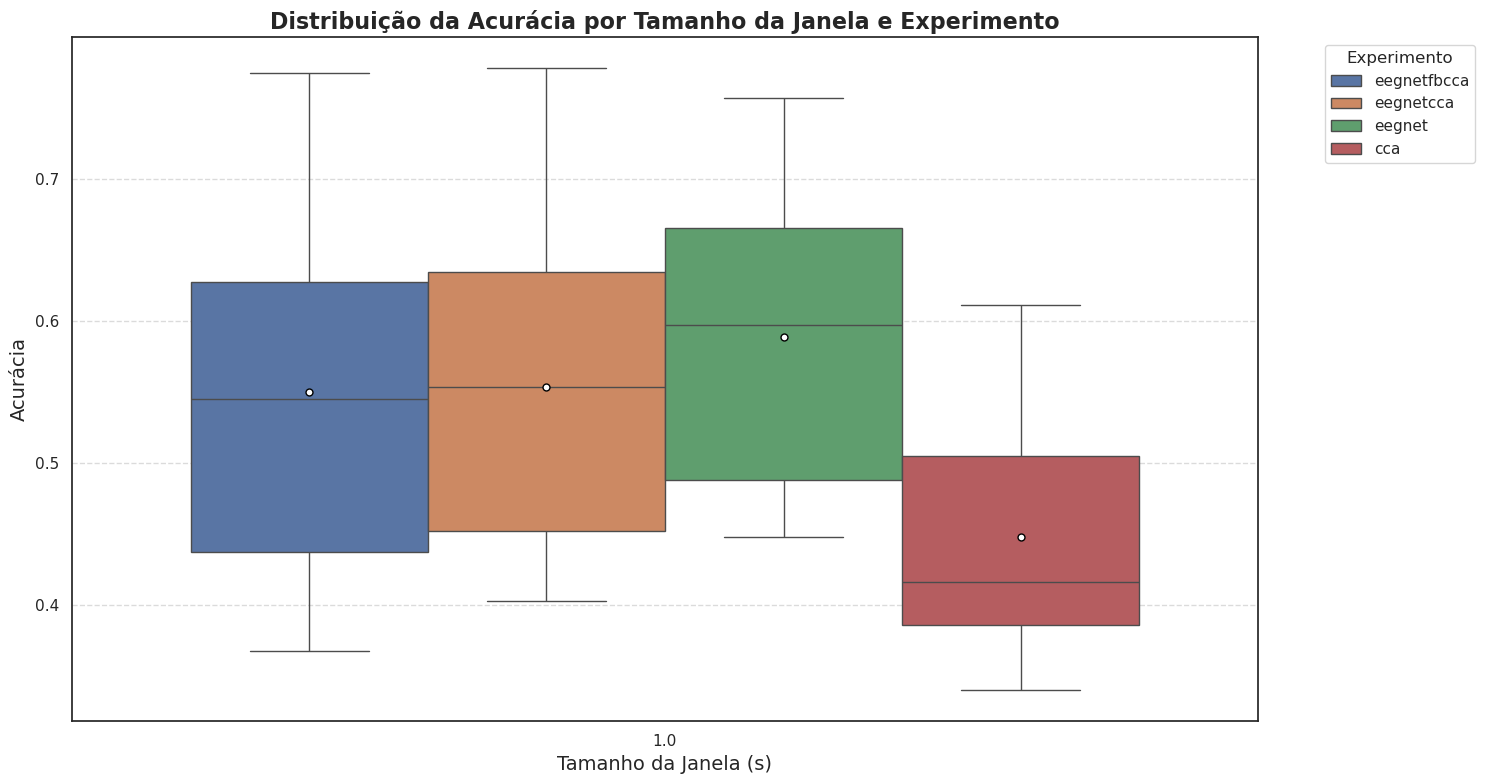

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for accuracy
plt.figure(figsize=(15, 8))

# Define palette if custom_palette is not fully defined for all experiments
available_experiments = sorted(results["experiment"].unique())
palette = {exp: custom_palette.get(exp, None) for exp in available_experiments}

sns.boxplot(
    data=results[results["experiment"].isin(experiment_order)],
    x="window",
    y="acuracia",
    hue="experiment",
    # palette=palette,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":5}
)

plt.title("Distribuição da Acurácia por Tamanho da Janela e Experimento", fontsize=16, fontweight="bold")
plt.xlabel("Tamanho da Janela (s)", fontsize=14)
plt.ylabel("Acurácia", fontsize=14)
plt.legend(title="Experimento", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Destine

# Old version

ValueError: The palette dictionary is missing keys: {'eegnetcca', 'cca', 'eegnetfbcca'}

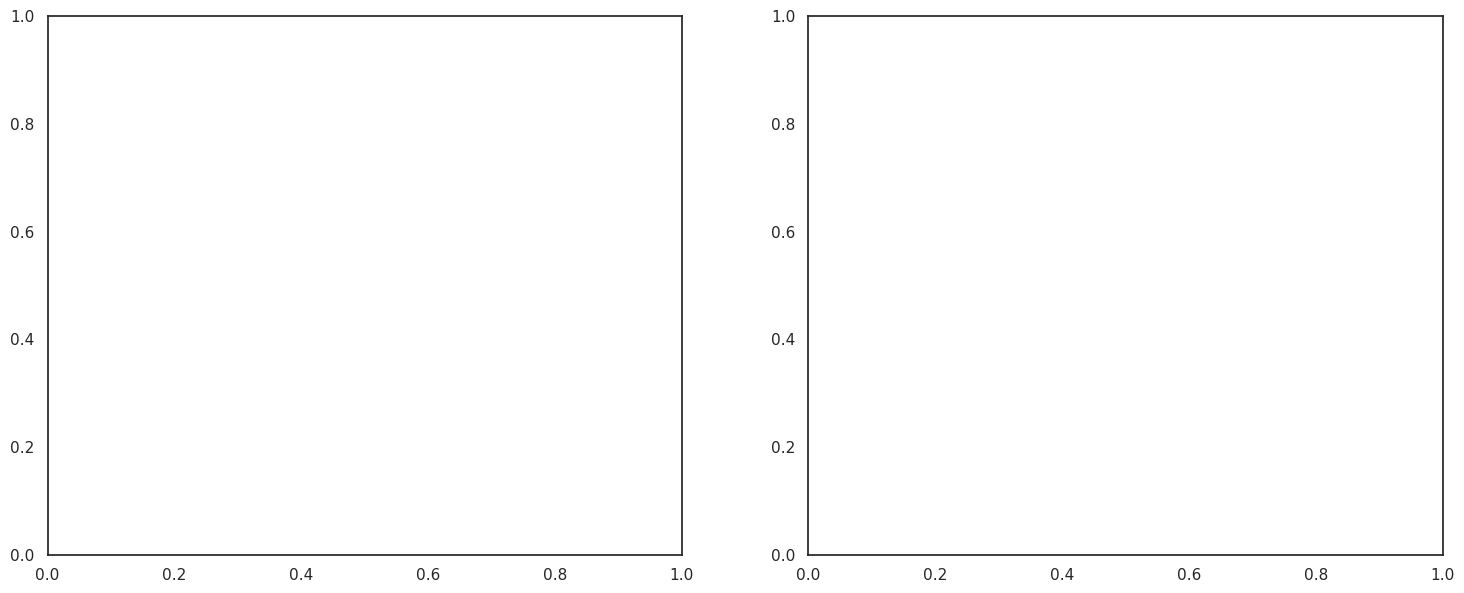

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="white")

# Custom color palette for paired experiments
custom_palette = {
    "CCA": "#156b00",  # Dark green
    "dnn": "#6baed6",  # Light blue
    "CCA_dnn": "#0854a6",  # Very dark blue (similar to dnn)
    "eegnet": "#ff9a56",  # Light orange
    "CCA_eegnet": "#d35400",  # Dark orange (similar to eegnet)
}

results_means_copy = results_means.copy()

results_means_copy["acuracia"] = (
    results_means_copy["acuracia"] * 100
)  # Convert to percentage
results_means_copy["acuracia_sem"] = (
    results_means_copy["acuracia_sem"] * 100
)  # Convert to percentage


# ============ PLOT 1: ACCURACY ============
ax = sns.lineplot(
    data=results_means_copy,
    x="window",
    y="acuracia",
    hue="experiment",
    marker="o",
    markersize=10,
    linewidth=2.5,
    palette=custom_palette,
    ax=ax1,
)

# Get colors for accuracy plot
colors = {}
lines = [line for line in ax1.get_lines()]
experiment_list = sorted(results_means["experiment"].unique())
for i, experiment in enumerate(experiment_list):
    colors[experiment] = lines[i].get_color()

# Add shaded areas for accuracy
for experiment in results_means_copy["experiment"].unique():
    data = results_means_copy[results_means_copy["experiment"] == experiment]
    data = data.sort_values("window")
    ax1.fill_between(
        data["window"],
        data["acuracia"] - data["acuracia_sem"],
        data["acuracia"] + data["acuracia_sem"],
        alpha=0.2,
        color=colors[experiment],
    )

# Add significance markers for accuracy plot
y_max_acc = results_means_copy["acuracia"].max()
y_offset_acc = y_max_acc * 0.06
comparison_pairs = [
    ("CCA_dnn", "dnn", "◆"),
    ("CCA_eegnet", "eegnet", "■"),
]

for window in sorted(results["window"].unique()):
    window_results = results_means_copy[results_means_copy["window"] == window]
    max_acc = window_results["acuracia"].max()
    sig_y_base = max_acc + y_offset_acc

    for idx, (exp1, exp2, symbol) in enumerate(comparison_pairs):
        if window in p_values_dict:
            p_val = None
            if (exp1, exp2) in p_values_dict[window]:
                p_val = p_values_dict[window][(exp1, exp2)]
            elif (exp2, exp1) in p_values_dict[window]:
                p_val = p_values_dict[window][(exp2, exp1)]

            if p_val is not None and p_val < 0.05:
                sig = get_significance(p_val)
                x_pos = window
                y_pos = sig_y_base + idx * 0.04
                marker_text = f"{symbol} {sig}"
                ax1.text(
                    x_pos,
                    y_pos,
                    marker_text,
                    ha="center",
                    fontsize=11,
                    fontweight="bold",
                    va="bottom",
                )

ax1.set_xlabel("Tamanho da janela (s)", fontsize=16, fontweight="bold")
ax1.set_xticks(results_means["window"].unique())
ax1.set_ylabel("Acurácia (%)", fontsize=16, fontweight="bold")
ax1.set_title("Acurácia por tamanho do sinal", fontsize=17, fontweight="bold")
ax1.legend(title="Experimento", loc="lower right", frameon=True, shadow=True)
ax1.set_ylim(top=100)
ax1.grid(axis="y", alpha=0.3, linestyle="--")

# ============ PLOT 2: ITR ============
ax = sns.lineplot(
    data=results_itr,
    x="window",
    y="itr",
    hue="experiment",
    marker="o",
    markersize=10,
    linewidth=2.5,
    palette=custom_palette,
    ax=ax2,
)

# Get colors for ITR plot
colors_itr = {}
lines_itr = [line for line in ax2.get_lines()]
for i, experiment in enumerate(experiment_list):
    colors_itr[experiment] = lines_itr[i].get_color()

# Add shaded areas for ITR
for experiment in results_itr["experiment"].unique():
    data = results_itr[results_itr["experiment"] == experiment]
    data = data.sort_values("window")
    ax2.fill_between(
        data["window"],
        data["itr"] - data["itr_sem"],
        data["itr"] + data["itr_sem"],
        alpha=0.2,
        color=colors_itr[experiment],
    )

# Add significance markers for ITR plot (using ITR p-values, not accuracy p-values)
y_max_itr = results_itr["itr"].max()
y_offset_itr = y_max_itr * 0.06

for window in sorted(results["window"].unique()):
    window_results = results_itr[results_itr["window"] == window]
    max_itr = window_results["itr"].max()
    sig_y_base = max_itr + y_offset_itr

    for idx, (exp1, exp2, symbol) in enumerate(comparison_pairs):
        if window in p_values_dict_itr:
            p_val = None
            if (exp1, exp2) in p_values_dict_itr[window]:
                p_val = p_values_dict_itr[window][(exp1, exp2)]
            elif (exp2, exp1) in p_values_dict_itr[window]:
                p_val = p_values_dict_itr[window][(exp2, exp1)]

            if p_val is not None and p_val < 0.05:
                sig = get_significance(p_val)
                x_pos = window
                y_pos = sig_y_base + idx * 0.04
                marker_text = f"{symbol} {sig}"
                ax2.text(
                    x_pos,
                    y_pos,
                    marker_text,
                    ha="center",
                    fontsize=11,
                    fontweight="bold",
                    va="bottom",
                )

ax2.set_xlabel("Tamanho do sinal (s)", fontsize=16, fontweight="bold")
ax2.set_xticks(results_itr["window"].unique())
ax2.set_ylabel("ITR (bpm)", fontsize=16, fontweight="bold")
ax2.set_title("ITR por tamanho do sinal", fontsize=17, fontweight="bold")
ax2.legend(title="Experimento", loc="lower right", frameon=True, shadow=True)
ax2.set_ylim(top=90)
ax2.grid(axis="y", alpha=0.3, linestyle="--")

# Add text box explaining symbols (p-values legend)
textstr = (
    "◆ CCA_dnn vs dnn\n■ CCA_eegnet vs eegnet\n*p < 0.05, **p < 0.01, ***p < 0.001"
)
props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
fig.text(
    0.5,
    0.02,
    textstr,
    ha="center",
    fontsize=11,
    bbox=props,
    family="monospace",
)

# Overall figure adjustments
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for the legend box

# Show the plot
plt.show()

# Optional: Save the figure
fig.savefig(
    "accuracy_itr_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Export Results

In [ ]:
# ============ COMBINE RESULTS: ACCURACY, ITR, AND P-VALUES ============
import pandas as pd

# Create a combined dataframe with accuracy, ITR, and their p-values

# Step 1: Merge accuracy means and ITR means
combined_means = results_means.copy()
combined_means = combined_means.rename(
    columns={"acuracia": "accuracy_mean", "acuracia_sem": "accuracy_sem"}
)

# Merge ITR data
combined_means = combined_means.merge(
    results_itr[["experiment", "window", "itr", "itr_sem"]].rename(
        columns={"itr": "itr_mean", "itr_sem": "itr_sem"}
    ),
    on=["experiment", "window"],
    how="left",
)

# Step 2: Add p-values for accuracy
# Flatten the p-values dictionaries into rows
acc_pvalues = []
for window, pairs in p_values_dict.items():
    for (exp1, exp2), p_val in pairs.items():
        # Create entries for both orderings
        acc_pvalues.append(
            {
                "window": window,
                "exp1": exp1,
                "exp2": exp2,
                "accuracy_pvalue": p_val,
                "accuracy_significance": get_significance(p_val),
            }
        )

acc_pvalues_df = pd.DataFrame(acc_pvalues)

# Step 3: Add p-values for ITR
itr_pvalues = []
for window, pairs in p_values_dict_itr.items():
    for (exp1, exp2), p_val in pairs.items():
        itr_pvalues.append(
            {
                "window": window,
                "exp1": exp1,
                "exp2": exp2,
                "itr_pvalue": p_val,
                "itr_significance": get_significance(p_val),
            }
        )

itr_pvalues_df = pd.DataFrame(itr_pvalues)

# Step 4: Merge p-values
pvalues_combined = acc_pvalues_df.merge(
    itr_pvalues_df, on=["window", "exp1", "exp2"], how="outer"
)

# Step 5: Create final combined table - one row per comparison
print("\n" + "=" * 120)
print("COMBINED RESULTS: ACCURACY MEANS, ITR MEANS, AND P-VALUES")
print("=" * 120)

print("\n1. EXPERIMENT MEANS (Accuracy and ITR by experiment and window):")
print(combined_means.to_string(index=False))

print(
    "\n\n2. STATISTICAL COMPARISONS (P-values for CCA_dnn vs dnn and CCA_eegnet vs eegnet):"
)
print(pvalues_combined.to_string(index=False))

# Step 6: Export to CSV
combined_means.to_csv("combined_means_accuracy_itr.csv", index=False)
pvalues_combined.to_csv("statistical_comparisons_pvalues.csv", index=False)

print("\n" + "=" * 120)
print("✓ CSV FILES EXPORTED:")
print("  1. combined_means_accuracy_itr.csv - Accuracy and ITR means with SEM")
print(
    "  2. statistical_comparisons_pvalues.csv - P-values and significance for all comparisons"
)
print("=" * 120)

: 

: 

: 

: 

: 

: 

# Matriz de confusão

In [ ]:
import ast
import re
import numpy as np

# Build results_cms with parsed confusion matrices
results_cms = results[["experiment", "window", "usuario", "confusion_matrix"]].copy()


def normalize_cm_string(s: str) -> str:
    """Normalize a confusion-matrix string so it becomes valid Python list syntax.
    Handles cases like '[[1 0][0 2]]', '[[1 0 2]\n [3 4 5]]', or missing commas.
    """
    s = s.strip()
    # Ensure outer brackets
    if not s.startswith("["):
        s = "[" + s
    if not s.endswith("]"):
        s = s + "]"

    # Put commas between closing and opening inner brackets: '][" -> '], ['
    s = re.sub(r"\]\s*\[", "], [", s)

    # Insert commas between numbers where whitespace is used as separator
    # e.g. '1 0' -> '1, 0', '1.0 -2' -> '1.0, -2'
    s = re.sub(r"(?<=[0-9\.\-])\s+(?=[0-9\.\-])", ", ", s)

    # Also handle cases like '[1,2 3]' -> ensure comma between '2' and '3'
    s = re.sub(r"(?<=[0-9\.\-]),\s*(?=[0-9\.\-])", ", ", s)

    return s


def parse_cm(cm):
    """Parse a confusion-matrix cell to a numpy array.
    Handles list/ndarray values or string representations with or without commas.
    Returns None for missing/NaN values.
    """
    if cm is None:
        return None
    if isinstance(cm, float) and np.isnan(cm):
        return None
    if isinstance(cm, (list, tuple, np.ndarray)):
        return np.array(cm)
    if isinstance(cm, str):
        s = cm.strip()
        # Normalize common missing-comma formats
        try:
            parsed = ast.literal_eval(s)
        except Exception:
            try:
                # Try normalizing separators and eval again
                s_norm = normalize_cm_string(s)
                parsed = ast.literal_eval(s_norm)
            except Exception:
                # final fallback to eval (only if necessary)
                parsed = eval(s)
        return np.array(parsed)
    # unknown type - try to coerce
    try:
        return np.array(cm)
    except Exception:
        return None


results_cms["cm_array"] = results_cms["confusion_matrix"].apply(parse_cm)

# Drop rows without a valid confusion matrix
results_cms = results_cms[results_cms["cm_array"].notnull()].copy()


# Helper to sum a sequence of confusion matrices (numpy arrays)
def sum_cms(seq):
    total = None
    for cm in seq:
        arr = np.array(cm)
        if total is None:
            total = np.zeros_like(arr, dtype=int)
        total = total + arr.astype(int)
    return total


# Sum per experiment, window, usuario
grouped_cms = (
    results_cms.groupby(["experiment", "window", "usuario"])["cm_array"]
    .apply(lambda s: sum_cms(s))
    .reset_index()
    .rename(columns={"cm_array": "confusion_matrix_sum"})
)

# Also produce a total per experiment & window (summing across usuarios)
grouped_total = (
    grouped_cms.groupby(["experiment", "window"])["confusion_matrix_sum"]
    .apply(lambda s: sum_cms(s))
    .reset_index()
    .rename(columns={"confusion_matrix_sum": "confusion_matrix_sum_all_users"})
)

# Quick sanity checks
print(f"Rows (experiment-window-user): {len(grouped_cms)}")
print(f"Rows (experiment-window total): {len(grouped_total)}")

grouped_cms.head(), grouped_total.head()

: 

: 

: 

: 

: 

: 

In [ ]:
classes = np.unique(list(range(8, 16)))
disp = ConfusionMatrixDisplay(
    confusion_matrix=grouped_total.iloc[0]["confusion_matrix_sum_all_users"],
    display_labels=classes,
)
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, cmap="Blues", xticks_rotation="vertical")
plt.show()

: 

: 

: 

: 

: 

: 